In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("data/database.sqlite")

# list every table in the database
pd.read_sql("SELECT name FROM sqlite_master WHERE type = 'table';", conn)

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


In [2]:
pd.read_sql("PRAGMA table_info(Match);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,country_id,INTEGER,0,None,0
2,2,league_id,INTEGER,0,None,0
3,3,season,TEXT,0,None,0
4,4,stage,INTEGER,0,None,0
...,...,...,...,...,...,...
110,110,GBD,NUMERIC,0,None,0
111,111,GBA,NUMERIC,0,None,0
112,112,BSH,NUMERIC,0,None,0
113,113,BSD,NUMERIC,0,None,0


In [3]:
pd.read_sql("""
    SELECT l.name AS league,
           COUNT(*) AS matches
    FROM Match AS m
    JOIN League AS l
      ON m.league_id = l.id
    GROUP BY l.name
    ORDER BY matches DESC;
""", conn)

,league,matches
0,Spain LIGA BBVA,3040
1,France Ligue 1,3040
2,England Premier League,3040
3,Italy Serie A,3017
4,Netherlands Eredivisie,2448
5,Germany 1. Bundesliga,2448
6,Portugal Liga ZON Sagres,2052
7,Poland Ekstraklasa,1920
8,Scotland Premier League,1824
9,Belgium Jupiler League,1728


In [4]:
df = pd.read_sql("""
    SELECT m.season,
           l.name              AS league,
           ht.team_long_name   AS home_team,
           at.team_long_name   AS away_team,
           m.home_team_goal,
           m.away_team_goal,
           m.B365H, m.B365D, m.B365A
    FROM Match AS m
    JOIN League AS l  ON m.league_id = l.id
    JOIN Team   AS ht ON m.home_team_api_id = ht.team_api_id
    JOIN Team   AS at ON m.away_team_api_id = at.team_api_id
    WHERE m.B365H IS NOT NULL;
""", conn)

df.shape

(22592, 9)

In [5]:
pd.read_sql("""
    SELECT l.name AS league,
           ROUND(AVG(m.home_team_goal + m.away_team_goal), 2) AS avg_goals
    FROM Match AS m
    JOIN League AS l
      ON m.league_id = l.id
    GROUP BY l.name
    ORDER BY avg_goals DESC;
""", conn)

,league,avg_goals
0,Netherlands Eredivisie,3.08
1,Switzerland Super League,2.93
2,Germany 1. Bundesliga,2.90
3,Belgium Jupiler League,2.80
4,Spain LIGA BBVA,2.77
5,England Premier League,2.71
6,Scotland Premier League,2.63
7,Italy Serie A,2.62
8,Portugal Liga ZON Sagres,2.53
9,France Ligue 1,2.44


In [6]:
import numpy as np

df["result"] = np.select(
    [df["home_team_goal"] > df["away_team_goal"],
     df["home_team_goal"] == df["away_team_goal"]],
    ["H", "D"],
    default="A"
)

df["result"].value_counts(normalize=True)

result
H    0.459056
A    0.287934
D    0.253010
Name: proportion, dtype: float64

In [7]:
df["home_raw"] = 1 / df["B365H"]
df["draw_raw"] = 1 / df["B365D"]
df["away_raw"] = 1 / df["B365A"]

df["margin"] = df["home_raw"] + df["draw_raw"] + df["away_raw"]

df["p_home"] = df["home_raw"] / df["margin"]
df["p_draw"] = df["draw_raw"] / df["margin"]
df["p_away"] = df["away_raw"] / df["margin"]

df["margin"].describe()

count    22592.000000
mean         1.061530
std          0.012725
min          1.017025
25%          1.059113
50%          1.063467
75%          1.066667
max          1.126011
Name: margin, dtype: float64

In [8]:
df[["p_home", "p_draw", "p_away"]].mean()

p_home    0.450510
p_draw    0.257833
p_away    0.291657
dtype: float64

In [9]:
long = pd.concat([
    pd.DataFrame({"outcome": "Home", "prob": df["p_home"], "won": df["result"] == "H"}),
    pd.DataFrame({"outcome": "Draw", "prob": df["p_draw"], "won": df["result"] == "D"}),
    pd.DataFrame({"outcome": "Away", "prob": df["p_away"], "won": df["result"] == "A"}),
])
long.shape

(67776, 3)

In [10]:
long["bucket"] = pd.cut(long["prob"], bins=np.arange(0, 1.05, 0.05))

calib = (long.groupby("bucket", observed=True)
             .agg(predicted=("prob", "mean"),
                  actual=("won", "mean"),
                  n=("won", "size"))
             .query("n >= 100"))
calib

,predicted,actual,n
bucket,,,
"(0.0, 0.05]",0.041480,0.027397,292
"(0.05, 0.1]",0.077794,0.057064,2173
"(0.1, 0.15]",0.126450,0.115950,3812
"(0.15, 0.2]",0.177163,0.170121,5355
"(0.2, 0.25]",0.227449,0.225089,7597
"(0.25, 0.3]",0.276532,0.270752,18781
"(0.3, 0.35]",0.319496,0.315616,6980
"(0.35, 0.4]",0.378356,0.388914,4384
"(0.4, 0.45]",0.427608,0.433348,4396


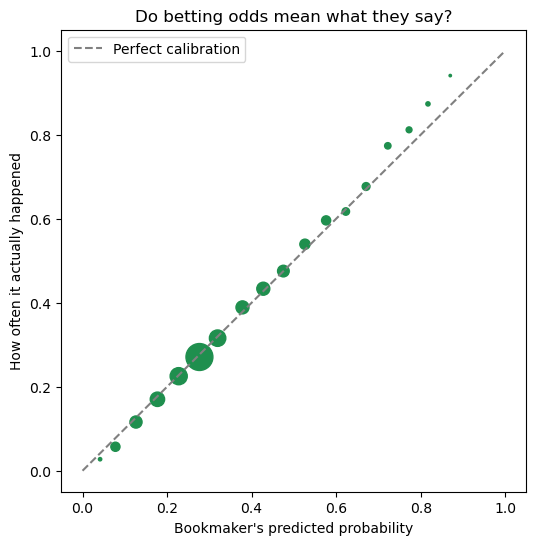

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.scatter(calib["predicted"], calib["actual"], s=calib["n"] / 50, color="#1f8f4e")
ax.set_xlabel("Bookmaker's predicted probability")
ax.set_ylabel("How often it actually happened")
ax.set_title("Do betting odds mean what they say?")
ax.legend()
plt.show()

In [12]:
# add the actual odds, in the same order as Cell D (home, draw, away)
long["odds"] = pd.concat([df["B365H"], df["B365D"], df["B365A"]]).values

# profit on a $1 bet: win -> odds - 1, lose -> -1
long["profit"] = np.where(long["won"], long["odds"] - 1, -1)

roi = (long.groupby("bucket", observed=True)
           .agg(avg_return=("profit", "mean"),
                n=("profit", "size"))
           .query("n >= 100"))
roi

,avg_return,n
bucket,,
"(0.0, 0.05]",-0.376712,292
"(0.05, 0.1]",-0.321215,2173
"(0.1, 0.15]",-0.137067,3812
"(0.15, 0.2]",-0.096601,5355
"(0.2, 0.25]",-0.067299,7597
"(0.25, 0.3]",-0.078098,18781
"(0.3, 0.35]",-0.069082,6980
"(0.35, 0.4]",-0.032151,4384
"(0.4, 0.45]",-0.046629,4396


In [13]:
pd.read_sql("""
    SELECT l.name AS league,
           COUNT(*) AS matches,
           ROUND(AVG(1.0/m.B365H + 1.0/m.B365D + 1.0/m.B365A) - 1, 4) AS avg_margin
    FROM Match AS m
    JOIN League AS l ON m.league_id = l.id
    WHERE m.B365H IS NOT NULL
    GROUP BY l.name
    ORDER BY avg_margin DESC;
""", conn)

,league,matches,avg_margin
0,Belgium Jupiler League,1706,0.0702
1,Netherlands Eredivisie,2445,0.0692
2,Portugal Liga ZON Sagres,2044,0.0690
3,Scotland Premier League,1824,0.0648
4,Italy Serie A,3011,0.0620
5,France Ligue 1,3036,0.0620
6,Spain LIGA BBVA,3039,0.0617
7,Germany 1. Bundesliga,2447,0.0616
8,England Premier League,3040,0.0423


In [14]:
plt.savefig("images/calibration.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

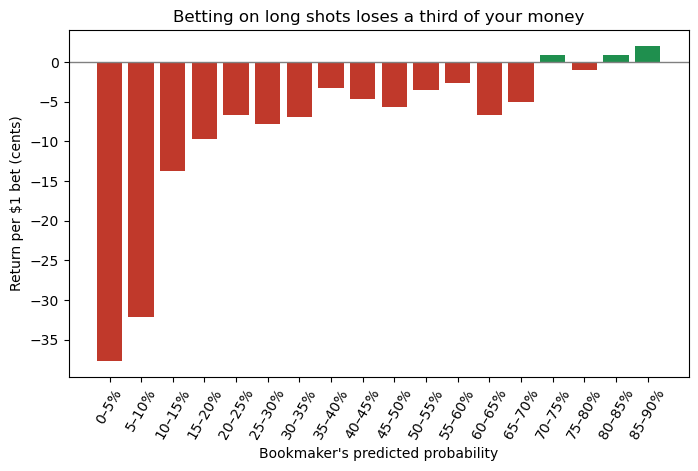

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [f"{int(b.left*100)}–{int(b.right*100)}%" for b in roi.index]
colors = ["#1f8f4e" if r >= 0 else "#c0392b" for r in roi["avg_return"]]
ax.bar(labels, roi["avg_return"] * 100, color=colors)
ax.axhline(0, color="gray", linewidth=1)
ax.set_xlabel("Bookmaker's predicted probability")
ax.set_ylabel("Return per $1 bet (cents)")
ax.set_title("Betting on long shots loses a third of your money")
plt.xticks(rotation=60)
plt.savefig("images/returns.png", dpi=150, bbox_inches="tight")
plt.show()

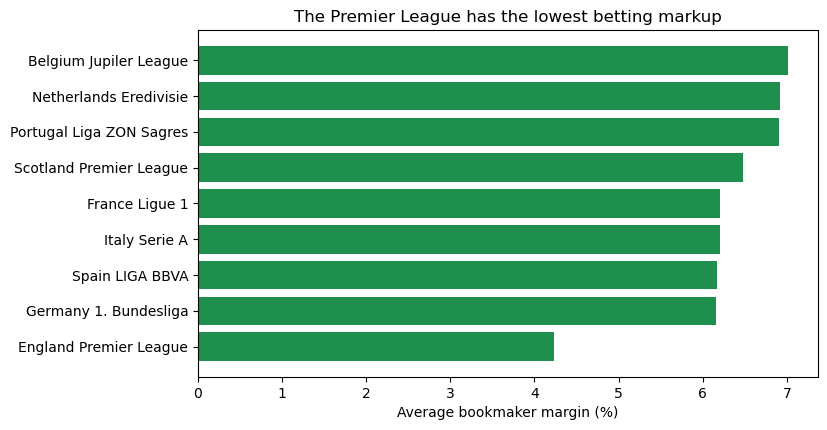

In [16]:
margins = pd.read_sql("""
    SELECT l.name AS league,
           AVG(1.0/m.B365H + 1.0/m.B365D + 1.0/m.B365A) - 1 AS avg_margin
    FROM Match AS m
    JOIN League AS l ON m.league_id = l.id
    WHERE m.B365H IS NOT NULL
    GROUP BY l.name
    ORDER BY avg_margin;
""", conn)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(margins["league"], margins["avg_margin"] * 100, color="#1f8f4e")
ax.set_xlabel("Average bookmaker margin (%)")
ax.set_title("The Premier League has the lowest betting markup")
plt.savefig("images/margins.png", dpi=150, bbox_inches="tight")
plt.show()